In [1]:
from matplotlib import pyplot as plt
import numpy as np

In [6]:
width = 1500
height = 1500
cutout_left = 1000
cutout_top = 500

vertices = [
    (0, height),
    (width, height),
    (width, cutout_top),
    (cutout_left, cutout_top),
    (cutout_left, 0),
    (0, 0)
]

edges = [
    [0, 1],
    [1, 2],
    [2, 3],
    [3, 4],
    [4, 5],
    [5, 0]
]


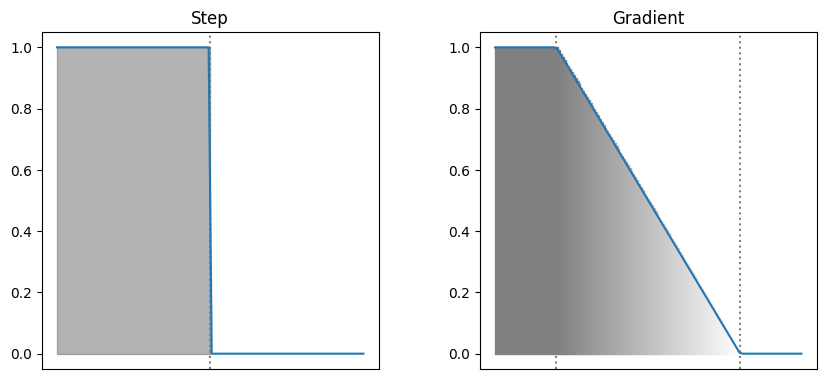

In [54]:
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

# Generate a step data set, a gradient line dataset, a concave curve, and a convex curve
# From the same starting to end value
x = np.linspace(0, 10, 100)
y1 = np.piecewise(x, [x < 5, x >= 5], [1, 0])

# Make a graph that is 1 until x=2, then linearly decreases to 0 at x=8, then stays at 0
y2 = np.piecewise(
    x,
    [x <= 2, np.logical_and(x > 2, x < 8), x >= 8],
    [lambda x: 1, lambda x: 1 - (x - 2) / (8 - 2), lambda x: 0]
)

# y2 = 1 - x / max(x)

# Plot the datasets in a 2x2 grid with one empty subplot, and make each subplot square
fig, axs = plt.subplots(1, 2, figsize=(10, 10))
fig.subplots_adjust(hspace=0.4, wspace=0.3)
# Set square aspect ratio for each subplot, scaling y so 0-1 matches 0-10 in x
# Hide the X axis values for all subplots
for ax in axs.flat:
    ax.set_aspect(10, adjustable='box')
    ax.set_xticks([])


# For the first plot, draw a vertical dashed line at x=5 to represent the step change
# then shade in dark grey the area under the step - ie 0, 0 to 0.5, 1.0.
axs[0].axvline(x=5, color='gray', linestyle='dotted')
axs[0].fill_betweenx(y=[0, 1], x1=0, x2=5, color='dimgray', alpha=0.5)


axs[0].plot(x, y1, label='Step')
axs[0].set_title('Step')

# For the second plot, draw vertical bars at x=2 and x=8 to represent the start and end of the gradient
# and shade lightly between them to represent the area of change
axs[1].axvline(x=2, color='gray', linestyle='dotted')
axs[1].axvline(x=8, color='gray', linestyle='dotted')

axs[1].fill_betweenx(y=[0, 1], x1=0, x2=2, color="grey", alpha=1)
# Draw a gradient from grey to white as a shaded triangle between (2, 1) and (8, 0)

# Define triangle vertices: (2,1), (8,0), (2,0)
triangle = np.array([[2, 1], [8, 0], [2, 0]])

# Create a polygon patch
poly = Polygon(triangle, closed=True)

# Create a gradient color array from dark grey to white
n_steps = 100
x_vals = np.linspace(2, 8, n_steps)
y_vals = np.linspace(1, 0, n_steps)
greys = np.linspace(0.5, 1, n_steps)
for i in range(n_steps - 1):
    # Interpolate y between 1 and 0
    y_top = y_vals[i]
    y_bot = 0
    axs[1].fill_betweenx(y=[0, y_top], x1=x_vals[i], x2=x_vals[i+1], color=(greys[i],) * 3, alpha=1)


axs[1].plot(x, y2, label='Gradient')
axs[1].set_title('Gradient')

plt.show()

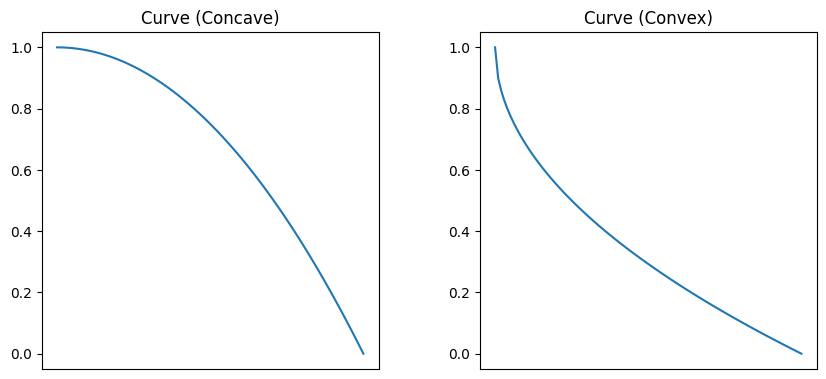

In [31]:
y3 = 1 - (x / max(x))**2
# Concave curve with greatest rate of change at start, least at end, from (0,0) to (10,1)
y4 = 1 - np.sqrt(x / max(x))
# Plot the datasets in a 2x2 grid with one empty subplot, and make each subplot square
fig, axs = plt.subplots(1, 2, figsize=(10, 10))
fig.subplots_adjust(hspace=0.4, wspace=0.3)

# Set square aspect ratio for each subplot, scaling y so 0-1 matches 0-10 in x
for ax in axs.flat:
    ax.set_aspect(10, adjustable='box')
    ax.set_xticks([])

axs[0].plot(x, y3, label='Curve')
axs[0].set_title('Curve (Concave)')

axs[1].plot(x, y4, label='Curve')
axs[1].set_title('Curve (Convex)')
plt.show()

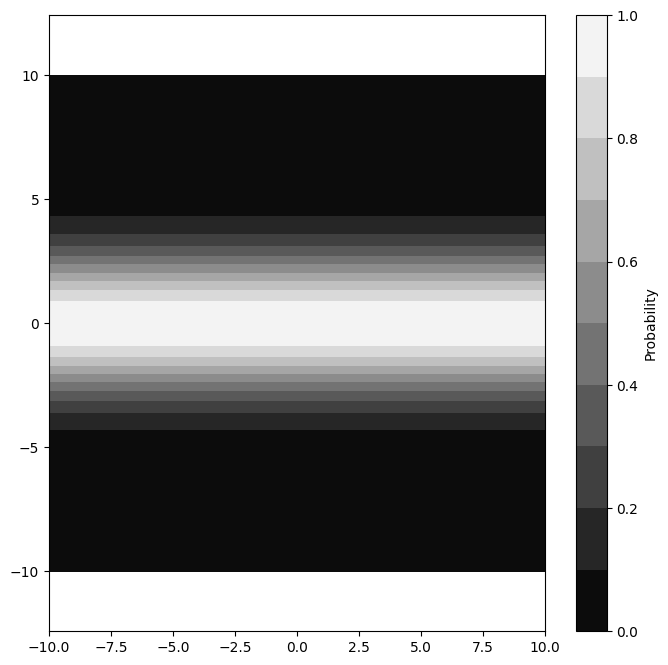

In [4]:
# Formulae - a horizontal line, at 0.
# With intensity 1 following the line, then dropping off smoothly to 0 above and below, over a distance of 8 units.
# The line spans about 20 units.
x = np.linspace(-10, 10, 400)
y = np.linspace(-10, 10, 400)
X, Y = np.meshgrid(x, y)
Z = np.exp(-((Y)**2) / (2 * (2**2)))
Z = Z / np.max(Z)  # Normalize to 0-1
plt.figure(figsize=(8, 8))
plt.contourf(X, Y, Z, levels=10, cmap='grey')
plt.colorbar(label='Probability')
# plt.title('Intensity around a Horizontal Line')
# plt.xlabel('X-axis')
# plt.ylabel('Y-axis')
plt.axis('equal')
plt.show()


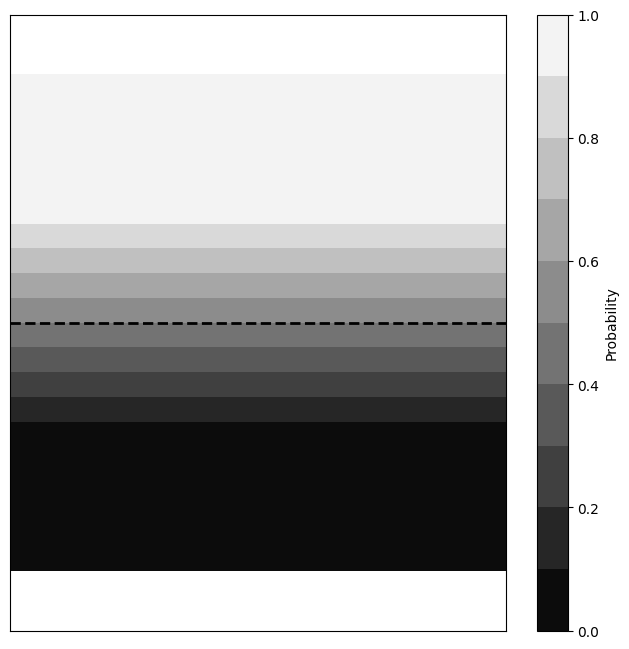

In [5]:
# Formulae - a horizontal line, at 0.
# With intensity 1 above the line, then dropping off smoothly to 0 below the line, with the line as a fuzzy boundary over a distance of 8 units.
# The line spans about 20 units.
x = np.linspace(-10, 10, 400)
y = np.linspace(-10, 10, 400)
X, Y = np.meshgrid(x, y)
# Use y2 to create a vertical transition along y, so Z is 1 above y=0, linearly decreases to 0 at y=-5, and 0 below
Z_profile = np.piecewise(
    y,
    [y >= 5, np.logical_and(y < 5, y > -5), y <= -5],
    [lambda y: 1, lambda y: (y + 5) / 10, lambda y: 0]
)
Z = np.tile(Z_profile, (X.shape[1], 1)).T


plt.figure(figsize=(8, 8))
plt.contourf(X, Y, Z, levels=10, cmap='grey')

# Add a horizontal line at y=0
plt.axhline(y=0, color='black', linestyle='dashed', linewidth=2)

plt.colorbar(label='Probability')
plt.axis('equal')
# Hide the axis values
plt.xticks([])
plt.yticks([])
plt.show()


In [7]:
margin = 100
# map x and map y are the map coordinates.
# A map is a view projected over a real world area. 
# The 0, 0 world x, y could be anywhere within the map.
mx_range = np.arange(-margin, width + margin)
my_range = np.arange(-margin, height + margin)
# Remember that the edges are all defined in world coordinates.

In [8]:
# Convert between our map representation, and the world coordinates relative to a zero
def world_to_map(wx, wy):
    mx = margin + wx
    my = margin + wy
    return mx, my

def map_to_world(mx, my):
    wx = mx - margin
    wy = my - margin
    return wx, wy
    

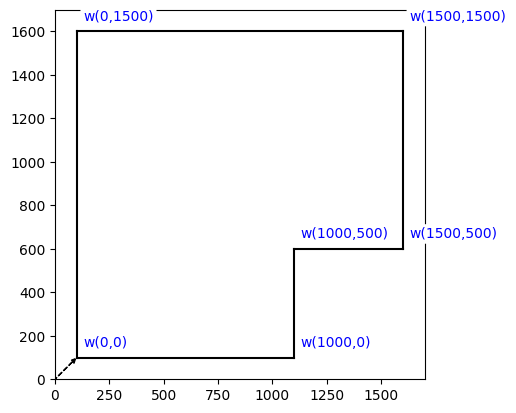

In [9]:
# Plot the edges of the arena, converting the coordinates as we go.
for edge in edges:
    v0 = vertices[edge[0]]
    v1 = vertices[edge[1]]
    mv0 = world_to_map(*v0)
    mv1 = world_to_map(*v1)
    plt.plot([mv0[0], mv1[0]], [mv0[1], mv1[1]], 'k-')
    # Label the starting vertices with their world coordinates
    plt.text(
        mv0[0] + 30, mv0[1] + 50,
        f"w({v0[0]},{v0[1]})",
        fontsize=10,
        color='blue',
        bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.2')
    )
# draw a dashed line from m(0,0) with arrow head to w(0,0) (margin, margin)
# plt.plot([margin, 0], [margin, 0], 'r--')
plt.arrow(0, 0, margin-20, margin-20, head_width=20, head_length=20, fc='k', ec='k', linestyle='dashed')


plt.xlim(0, width + 2 * margin)
plt.ylim(0, height + 2 * margin)
plt.gca().set_aspect('equal', adjustable='box')


In [66]:
mini_x_range = np.linspace(2, 5, num=4)
mini_y_range = np.linspace(1, 8, num=3)
min_map_x, mini_map_y = np.meshgrid(mini_x_range, mini_y_range)
min_map_x, mini_map_y

(array([[2., 3., 4., 5.],
        [2., 3., 4., 5.],
        [2., 3., 4., 5.]]),
 array([[1. , 1. , 1. , 1. ],
        [4.5, 4.5, 4.5, 4.5],
        [8. , 8. , 8. , 8. ]]))